In [12]:
PALETTE = [
    "#5F4690",
    "#1D6996",
    "#38A6A5",
    "#0F8554",
    "#73AF48",
    "#EDAD08",
    "#E17C05",
    "#CC503E",
    "#94346E",
    "#6F4070",
    "#994E95",
    "#FF89F9",
    "#FBC5F9",
    "#666666",
]

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MultipleLocator
from tueplots import bundles, figsizes

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [14]:
metrics = ['nice_factor', 'forgiving_factor', 'retaliatory_factor', 'troublemaking_factor', 'emulative_factor']
metric_names = {
    'nice_factor': 'Nice',
    'forgiving_factor': 'Forgiving',
    'retaliatory_factor': 'Retaliatory',
    'troublemaking_factor': 'Troublemaking',
    'emulative_factor': 'Emulative',
}
metric_colors = {
    'nice_factor': PALETTE[4],
    'forgiving_factor': PALETTE[2],
    'retaliatory_factor': PALETTE[7],
    'troublemaking_factor': PALETTE[1],
    'emulative_factor': PALETTE[9],
}
models = ['ministral-3:8b', 'ministral-3:14b', 'qwen3.5:9b', 'random']
model_names = {
    'ministral-3:8b': 'Ministral-3:8B',
    'ministral-3:14b': 'Ministral-3:14B',
    'qwen3.5:9b': 'Qwen3.5:9B',
    'random': 'Random',
}

baseline_prompt_file = 'prompts/baseline.json'
personas_prompt_files = [
    'prompts/compassionate.json',
    'prompts/baseline.json',
    'prompts/narcissistic.json',
]
tones_prompt_files = [
    'prompts/polite.json',
    'prompts/baseline.json',
    'prompts/rude.json',
]
score_prompt_files = [
    'prompts/baseline.json',
    'prompts/x10.json',
    'prompts/x100.json',
]
stay_go_prompt_files = [
    'prompts/baseline.json',
    'prompts/stay_go.json',
]
independent_payoffs_prompt_files = [
    'prompts/independent_payoffs_coop.json',
    'prompts/baseline.json',
    'prompts/independent_payoffs_defect.json',
]
prompt_file_names = {
    'prompts/baseline.json': 'B',
    'prompts/compassionate.json': 'C',
    'prompts/narcissistic.json': 'N',
    'prompts/polite.json': 'P',
    'prompts/rude.json': 'R',
    'prompts/x10.json': 'T',
    'prompts/x100.json': 'H',
    'prompts/independent_payoffs_coop.json': 'IC',
    'prompts/independent_payoffs_defect.json': 'ID',
}
prompt_file_action_names = {
    'prompts/baseline.json': 'C/D',
    'prompts/stay_go.json': 'S/G',
}
prompt_file_multiplier = {
    'prompts/baseline.json': 1,
    'prompts/x10.json': 10,
    'prompts/x100.json': 100,
}

all_prompt_files = [
    "prompts/baseline.json", 
    "prompts/compassionate.json", 
    "prompts/narcissistic.json", 
    "prompts/polite.json", 
    "prompts/rude.json", 
    "prompts/x10.json", 
    "prompts/x100.json"
]

In [15]:
df = pd.read_csv("results/analyzed_results.csv")

def bootstrap_ci(x, n_bootstrap=5000, ci=95):
    x = np.asarray(x.dropna())

    if len(x) == 0:
        return (np.nan, np.nan)

    boot = np.random.choice(
        x,
        size=(n_bootstrap, len(x)),
        replace=True
    ).mean(axis=1)

    alpha = (100 - ci) / 2
    return (
        np.mean(x),
        np.percentile(boot, alpha),
        np.percentile(boot, 100 - alpha)
    )

rows = []

for (model, prompt_file), group in df.groupby(["model", "prompt_file"]):
    row = {
        "model": model,
        "prompt_file": prompt_file
    }
    print(f"Processing model={model}, prompt_file={prompt_file} with {len(group)} samples")

    for metric in metrics + ['player_a_total_score', 'player_b_total_score']:
        row[metric] = bootstrap_ci(group[metric])

    rows.append(row)

agg_df = pd.DataFrame(rows)

Processing model=ministral-3:14b, prompt_file=prompts/baseline.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/compassionate.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/independent_payoffs_coop.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/independent_payoffs_defect.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/narcissistic.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/polite.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/rude.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/stay_go.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/x10.json with 30 samples
Processing model=ministral-3:14b, prompt_file=prompts/x100.json with 30 samples
Processing model=ministral-3:8b, prompt_file=prompts/baseline.json with 30 samples
Processing model=ministral-3:8b, prompt_file=promp

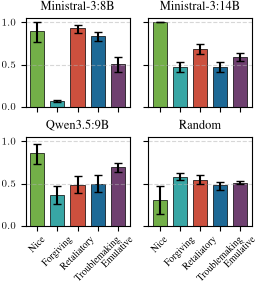


Saved to plots/baselines.pdf


In [16]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=2, ncols=2, height_to_width_ratio=1.1, rel_width=0.48))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(2, 2, sharey=True, sharex=True)
for model, ax in zip(models, axes.flat):
    subset = agg_df[(agg_df["model"] == model) & (agg_df["prompt_file"] == baseline_prompt_file)]
    assert len(subset) == 1
    model_metrics = subset.iloc[0]
    model_metrics = [model_metrics[metric] for metric in metrics]
    means = np.array([m[0] for m in model_metrics])
    los = np.array([m[1] for m in model_metrics])
    his = np.array([m[2] for m in model_metrics])
    colors = [metric_colors[metric] for metric in metrics]
    x = np.arange(len(model_metrics))
    bars = ax.bar(x, means, yerr=[means - los, his - means], capsize=3, color=colors,
                      edgecolor="black", linewidth=0.5, width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([metric_names[metric] for metric in metrics], rotation=45, ha="center")
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")
    ax.set_title(model_names[model])

plt.savefig("plots/baselines.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/baselines.pdf")

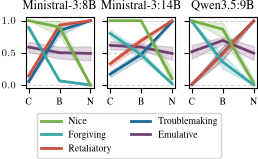


Saved to plots/personas.pdf


In [17]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.3, rel_width=0.48))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models[:-1], axes):
    for metric in reversed(metrics):
        means = []
        los = []
        his = []
        for pf in personas_prompt_files:
            subset = agg_df[
                (agg_df["model"] == model) &
                (agg_df["prompt_file"] == pf)
            ]

            assert len(subset) == 1

            row = subset.iloc[0]
            mean, lo, hi = row[metric]
            means.append(mean)
            los.append(lo)
            his.append(hi)
        means = np.array(means)
        los = np.array(los)
        his = np.array(his)
        x = np.arange(len(personas_prompt_files))
        ax.plot(
            x,
            means,
            label=metric_names[metric],
            color=metric_colors[metric],
            linewidth=2
        )
        ax.fill_between(
            x,
            los,
            his,
            color=metric_colors[metric],
            alpha=0.2
        )
    ax.set_xticks(x)
    ax.set_xticklabels([prompt_file_names[pf] for pf in personas_prompt_files])
    ax.set_title(model_names[model])
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = axes[0].get_legend_handles_labels()
handles, labels = reversed(handles), reversed(labels)

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.45)
)

plt.savefig("plots/personas.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/personas.pdf")

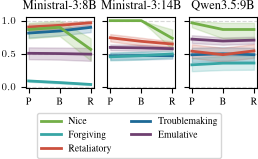


Saved to plots/tones.pdf


In [18]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.3, rel_width=0.48))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models[:-1], axes):
    for metric in reversed(metrics):
        means = []
        los = []
        his = []
        for pf in tones_prompt_files:
            subset = agg_df[
                (agg_df["model"] == model) &
                (agg_df["prompt_file"] == pf)
            ]

            assert len(subset) == 1

            row = subset.iloc[0]
            mean, lo, hi = row[metric]
            means.append(mean)
            los.append(lo)
            his.append(hi)
        means = np.array(means)
        los = np.array(los)
        his = np.array(his)
        x = np.arange(len(tones_prompt_files))
        ax.plot(
            x,
            means,
            label=metric_names[metric],
            color=metric_colors[metric],
            linewidth=2
        )
        ax.fill_between(
            x,
            los,
            his,
            color=metric_colors[metric],
            alpha=0.2
        )
    ax.set_xticks(x)
    ax.set_xticklabels([prompt_file_names[pf] for pf in tones_prompt_files])
    ax.set_title(model_names[model])
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = axes[0].get_legend_handles_labels()
handles, labels = reversed(handles), reversed(labels)

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.45)
)

plt.savefig("plots/tones.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/tones.pdf")

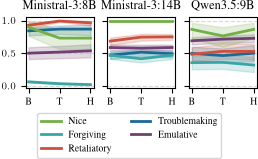


Saved to plots/payoff_magnitudes.pdf


In [19]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.3, rel_width=0.48))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models[:-1], axes):
    for metric in reversed(metrics):
        means = []
        los = []
        his = []
        for pf in score_prompt_files:
            subset = agg_df[
                (agg_df["model"] == model) &
                (agg_df["prompt_file"] == pf)
            ]

            assert len(subset) == 1

            row = subset.iloc[0]
            mean, lo, hi = row[metric]
            means.append(mean)
            los.append(lo)
            his.append(hi)
        means = np.array(means)
        los = np.array(los)
        his = np.array(his)
        x = np.arange(len(score_prompt_files))
        ax.plot(
            x,
            means,
            label=metric_names[metric],
            color=metric_colors[metric],
            linewidth=2
        )
        ax.fill_between(
            x,
            los,
            his,
            color=metric_colors[metric],
            alpha=0.2
        )
    ax.set_xticks(x)
    ax.set_xticklabels([prompt_file_names[pf] for pf in score_prompt_files])
    ax.set_title(model_names[model])
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = axes[0].get_legend_handles_labels()
handles, labels = reversed(handles), reversed(labels)

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.45)
)

plt.savefig("plots/payoff_magnitudes.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/payoff_magnitudes.pdf")

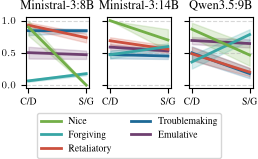


Saved to plots/stay_go.pdf


In [20]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.3, rel_width=0.48))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models[:-1], axes):
    for metric in reversed(metrics):
        means = []
        los = []
        his = []
        for pf in stay_go_prompt_files:
            subset = agg_df[
                (agg_df["model"] == model) &
                (agg_df["prompt_file"] == pf)
            ]

            assert len(subset) == 1

            row = subset.iloc[0]
            mean, lo, hi = row[metric]
            means.append(mean)
            los.append(lo)
            his.append(hi)
        means = np.array(means)
        los = np.array(los)
        his = np.array(his)
        x = np.arange(len(stay_go_prompt_files))
        ax.plot(
            x,
            means,
            label=metric_names[metric],
            color=metric_colors[metric],
            linewidth=2
        )
        ax.fill_between(
            x,
            los,
            his,
            color=metric_colors[metric],
            alpha=0.2
        )
    ax.set_xticks(x)
    ax.set_xticklabels([prompt_file_action_names[pf] for pf in stay_go_prompt_files])
    ax.set_title(model_names[model])
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = axes[0].get_legend_handles_labels()
handles, labels = reversed(handles), reversed(labels)

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.45)
)

plt.savefig("plots/stay_go.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/stay_go.pdf")

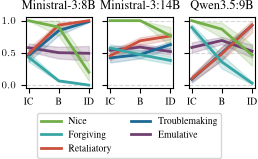


Saved to plots/independent_payoffs.pdf


In [21]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.3, rel_width=0.48))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models[:-1], axes):
    for metric in reversed(metrics):
        means = []
        los = []
        his = []
        for pf in independent_payoffs_prompt_files:
            subset = agg_df[
                (agg_df["model"] == model) &
                (agg_df["prompt_file"] == pf)
            ]

            assert len(subset) == 1

            row = subset.iloc[0]
            mean, lo, hi = row[metric]
            means.append(mean)
            los.append(lo)
            his.append(hi)
        means = np.array(means)
        los = np.array(los)
        his = np.array(his)
        x = np.arange(len(independent_payoffs_prompt_files))
        ax.plot(
            x,
            means,
            label=metric_names[metric],
            color=metric_colors[metric],
            linewidth=2
        )
        ax.fill_between(
            x,
            los,
            his,
            color=metric_colors[metric],
            alpha=0.2
        )
    ax.set_xticks(x)
    ax.set_xticklabels([prompt_file_names[pf] for pf in independent_payoffs_prompt_files])
    ax.set_title(model_names[model])
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = axes[0].get_legend_handles_labels()
handles, labels = reversed(handles), reversed(labels)

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, -0.45)
)

plt.savefig("plots/independent_payoffs.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/independent_payoffs.pdf")